In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

ROOT = Path.cwd().parent
ROOT

PosixPath('/Users/I550854/Documents/Master Thesis/gdpa-benchmark')

In [2]:
gpqa_diamond = pd.read_csv(ROOT / "dataset/gpqa_diamond.csv")
gpqa_diamond = gpqa_diamond[["Question", "Correct Answer", "Incorrect Answer 1", "Incorrect Answer 2", "Incorrect Answer 3", "Explanation", "High-level domain", "Subdomain", "Writer's Difficulty Estimate", "Expert Validator Accuracy", "Non-Expert Validator Accuracy"]]

gpqa_diamond.head(1)

,Question,Correct Answer,Incorrect Answer 1,Incorrect Answer 2,Incorrect Answer 3,Explanation,High-level domain,Subdomain,Writer's Difficulty Estimate,Expert Validator Accuracy,Non-Expert Validator Accuracy
0,"Two quantum states with energies E1 and E2 have a lifetime of 10^-9 sec and 10^-8 sec, respectively. We want to clearly distinguish these two energy levels. Which one of the following options could be their energy difference so that they can be clearly resolved?\n",10^-4 eV,10^-11 eV,10^-8 eV\n,10^-9 eV,"According to the uncertainty principle, Delta E* Delta t=hbar/2. Delta t is the lifetime and Delta E is the width of the energy level. With Delta t=10^-9 s==> Delta E1= 3.3 10^-7 ev. And Delta t=10^-11 s gives Delta E2=3.310^-8 eV.\nTherefore, the energy difference between the two states must be significantly greater than 10^-7 ev. So the answer is 10^-4 ev.",Physics,Physics (general),Hard undergraduate level (could be a question on a hard undergraduate exam for students majoring in the subject),1.0,0.0


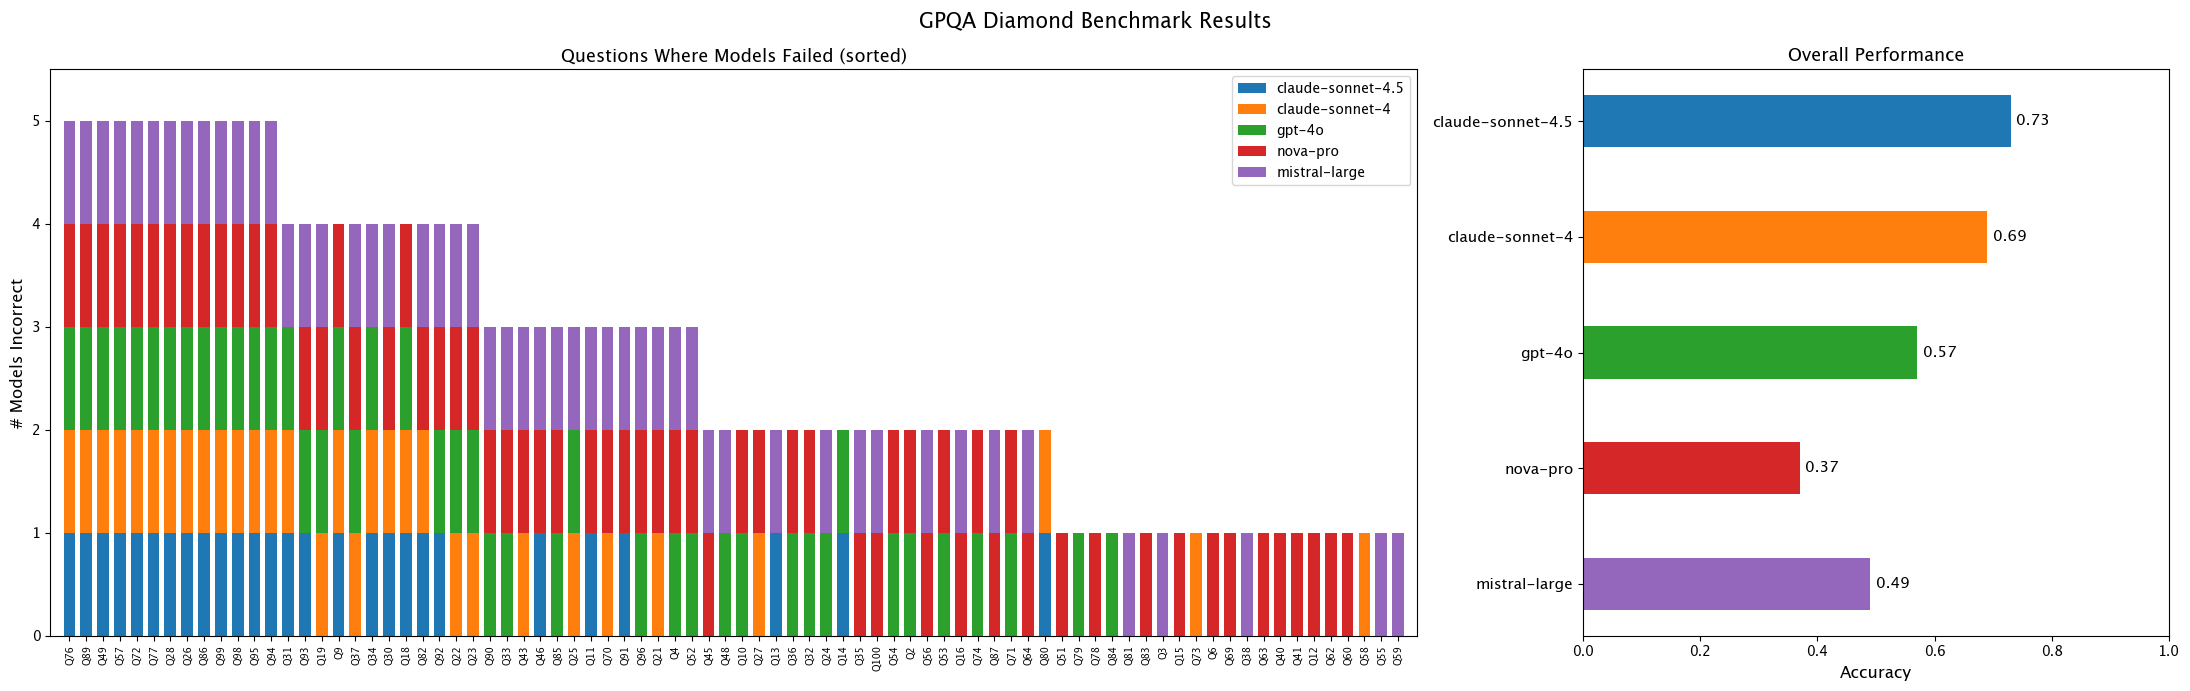

In [ ]:
import json
import matplotlib.pyplot as plt
import numpy as np

results_dir = ROOT / "results/benchmarking"
model_data = {}

for path in sorted(results_dir.glob("*.json")):
    data = json.loads(path.read_text())
    model_data[data["model"]] = {q["index"]: q["correct"] for q in data["questions"]}

models = list(model_data.keys())
question_ids = sorted({qid for m in model_data.values() for qid in m})
colors = plt.cm.tab10.colors

incorrect = {
    m: [0 if model_data[m].get(qid, True) else 1 for qid in question_ids]
    for m in models
}

# Only keep questions where at least one model was wrong
totals = np.array([sum(incorrect[m][i] for m in models) for i, _ in enumerate(question_ids)])
mask = totals > 0
filtered_qids = [question_ids[i] for i in np.argsort(totals)[::-1] if totals[i] > 0]
order = [question_ids.index(qid) for qid in filtered_qids]

tick_fontsize = max(7, min(11, int(120 / max(len(filtered_qids), 1))))

fig, (ax_detail, ax_overall) = plt.subplots(
    1, 2,
    figsize=(22, 7),
    gridspec_kw={"width_ratios": [7, 3]}
)

# --- Left: stacked incorrects per question ---
bottoms = np.zeros(len(filtered_qids))
for j, model in enumerate(models):
    values = [incorrect[model][i] for i in order]
    ax_detail.bar(range(len(filtered_qids)), values, bottom=bottoms,
                  label=model, color=colors[j % len(colors)], width=0.7)
    bottoms += np.array(values)

ax_detail.set_xticks(range(len(filtered_qids)))
ax_detail.set_xticklabels([f"Q{qid}" for qid in filtered_qids],
                           rotation=90, fontsize=tick_fontsize)
ax_detail.set_ylabel("# Models Incorrect", fontsize=12)
ax_detail.set_title("Questions Where Models Failed (sorted)", fontsize=13)
ax_detail.legend(loc="upper right", fontsize=10)
ax_detail.set_ylim(0, len(models) + 0.5)
ax_detail.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax_detail.margins(x=0.01)

# --- Right: overall model accuracy ---
accuracies = [sum(model_data[m].values()) / len(model_data[m]) for m in models]
bars = ax_overall.barh(models, accuracies, color=colors[:len(models)], height=0.45)
ax_overall.set_xlim(0, 1)
ax_overall.set_xlabel("Accuracy", fontsize=12)
ax_overall.set_title("Overall Performance", fontsize=13)
ax_overall.bar_label(bars, fmt="%.2f", padding=4, fontsize=11)
ax_overall.tick_params(axis='y', labelsize=11)
ax_overall.invert_yaxis()

plt.suptitle("GPQA Diamond Benchmark Results", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

There are questions in GPQA-Diamond where all models fail with N=1 (no self-loops). Thus, I will use one of those questions here for the analysis where **#incorrect=5**. This includes (among others):
- Q76
- Q89
- Q49
- **Q57** (index 56 in df)
- Q72

Regarding the model choice, I will start with mistral-large. Because it does not achieve great performance, its **hosted by SAP** (no token costs associated with it), and the **inference time is 2-3x faster** compared to the Claude models.

In [16]:
gpqa_diamond.loc[[56]]

,Question,Correct Answer,Incorrect Answer 1,Incorrect Answer 2,Incorrect Answer 3,Explanation,High-level domain,Subdomain,Writer's Difficulty Estimate,Expert Validator Accuracy,Non-Expert Validator Accuracy
56,"Given the measured phase shifts $\delta_o=90^o, \delta_1=67^o, \delta_2=55, \delta_3=30^o$ and $\delta_4=13^o$ in an experiment of elastic scattering of $50~MeV$ electrons from a nuclear target. Ignore rest of the phase shifts. Calculate the imaginary part of the scattering amplitude along the incident beam direction.",251.271 fm\n,177.675 fm\n,355.351 fm,87163.4 fm\n,"This question asks for the imaginary part of the forward angle amplitude for the given scattering information. Using partial wave analysis one has the expressions for both the cross section and the forward angle amplitude (scattering angle $\theta=0$) in terms of the partial wave phase shifts. Im F(0) = 1/k \sum_0^{\infty}(2 l +1)\sin^2\delta_l. Also, the cross section is $\sigma_{tot} = 4\pi/k^2 \sum_0^{\infty}(2l+1)\sin^2\delta_l$. Here, k is the wave number. Using these expression one can simply get the imaginary part of the amplitude at forward angle scattering.",Physics,Quantum Mechanics,Hard undergraduate level (could be a question on a hard undergraduate exam for students majoring in the subject),1.0,0.333333
